
# ML Pipeline Revision Notebook — Seagate HDD SMART Data

A from-scratch walk through the standard ML pipeline, using the real Q1 2026 Seagate
drive dataset from this project as the running example:

```
Raw data -> Ingestion -> EDA -> Cleaning -> Feature Engineering -> PCA
         -> Preprocessing -> Model Training -> Evaluation
```

Goal: rebuild each stage yourself, with the math written out next to the code, so the
concepts stick independently of any one library's API.



## 1. Data Ingestion

The full `seagate_hdd_q1_2026.parquet` has **~10.07M** daily drive-SMART readings but
only **406** failure events — extremely imbalanced (failure rate ≈ 0.004%).

For a notebook you can iterate on quickly, we pull:
- every failure row (all 406), and
- a random sample of healthy-drive rows (~40k)

This keeps the *signal* (rare failures) while making the dataset small enough to
explore interactively. Real production pipelines would use the full 10M rows.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid')
RNG = 42

DATA_PATH = 'data/seagate_hdd_q1_2026.parquet'
full = pd.read_parquet(DATA_PATH)
print('Full dataset shape:', full.shape)
full.head()


Full dataset shape: (10068229, 11)


,date,serial_number,model,capacity_bytes,failure,smart_5_raw,smart_9_raw,smart_187_raw,smart_188_raw,smart_197_raw,smart_198_raw
0,2026-01-01,S2ZYJ9AFA09524,ST500LM012 HN,500107862016,0,0.0,88041.0,NaN,NaN,0.0,0.0
1,2026-01-01,S2ZYJ9BF508124,ST500LM012 HN,500107862016,0,0.0,91539.0,NaN,NaN,0.0,0.0
2,2026-01-01,S2ZYJ9BF508128,ST500LM012 HN,500107862016,0,0.0,90052.0,NaN,NaN,0.0,0.0
3,2026-01-01,S2ZYJ9BF508141,ST500LM012 HN,500107862016,0,0.0,91860.0,NaN,NaN,0.0,0.0
4,2026-01-01,S2ZYJ9BF508148,ST500LM012 HN,500107862016,0,0.0,89796.0,NaN,NaN,0.0,0.0



> **Inference:** 10,068,229 rows across just 11 columns — one row per drive per day.
> Notice `smart_187_raw`/`smart_188_raw` are `NaN` for these first rows even though
> `smart_5_raw`/`smart_9_raw` are populated: different drive models report different
> SMART attributes, so missingness here is *model-dependent*, not random — that will
> matter when we decide how to fill it in Section 3.


In [2]:

failures = full[full['failure'] == 1]
healthy_sample = full[full['failure'] == 0].sample(n=40_000, random_state=RNG)

df = pd.concat([failures, healthy_sample], ignore_index=True)
df = df.sample(frac=1, random_state=RNG).reset_index(drop=True)  # shuffle

print('Working sample shape:', df.shape)
print('Failure rate in sample:', df['failure'].mean())
df.head()


Working sample shape: (40406, 11)
Failure rate in sample: 0.010048012671385437


,date,serial_number,model,capacity_bytes,failure,smart_5_raw,smart_9_raw,smart_187_raw,smart_188_raw,smart_197_raw,smart_198_raw
0,2026-02-12,ZLW0HBSN,ST12000NM001G,12000138625024,0,0.0,50401.0,0.0,0.0,0.0,0.0
1,2026-03-23,ZL2MLS8C,ST16000NM001G,16000900661248,0,0.0,17159.0,0.0,0.0,0.0,0.0
2,2026-02-26,ZL2LGKW3,ST16000NM001G,16000900661248,0,0.0,37830.0,0.0,0.0,0.0,0.0
3,2026-03-27,ZA12NQT5,ST8000DM002,8001563222016,0,0.0,4958.0,0.0,9.0,0.0,0.0
4,2026-03-25,ZL2L8BK5,ST16000NM001G,16000900661248,0,0.0,38441.0,0.0,0.0,0.0,0.0



> **Inference:** the sample landed at 40,406 rows with a **1.0%** failure rate — about
> **250x richer** than the true 0.004% fleet-wide rate. That's by design (we kept every
> failure and subsampled the healthy majority), but it means any metric we compute from
> here on describes *this enriched sample*, not the real-world base rate. We'll need to
> keep that in mind — e.g. a model's precision here would be far higher than its
> precision on the true, far-more-imbalanced fleet.



## 2. Exploratory Data Analysis (EDA)

### 2.1 Central tendency & spread

For a feature $x_1, \dots, x_n$:

$$
\bar{x} = \frac{1}{n}\sum_{i=1}^n x_i \qquad
\text{median} = x_{\left(\frac{n+1}{2}\right)} \qquad
\text{mode} = \arg\max_v \; \text{count}(x_i = v)
$$

$$
\text{Var}(x) = \sigma^2 = \frac{1}{n-1}\sum_{i=1}^n (x_i - \bar{x})^2
\qquad
\sigma = \sqrt{\sigma^2}
$$

Pandas uses the **sample** variance (dividing by $n-1$, Bessel's correction) by default.


In [3]:

numeric_cols = ['capacity_bytes', 'smart_5_raw', 'smart_9_raw',
                 'smart_187_raw', 'smart_188_raw', 'smart_197_raw', 'smart_198_raw']

desc = df[numeric_cols].describe().T
desc['mode'] = [df[c].mode().iloc[0] for c in numeric_cols]
desc


,count,mean,std,min,25%,50%,75%,max,mode
capacity_bytes,40406.0,1.370302e+13,4.217671e+12,5.001079e+11,1.200014e+13,1.400052e+13,1.600090e+13,2.400028e+13,1.600090e+13
smart_5_raw,40372.0,2.333196e+02,2.808020e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.552800e+04,0.000000e+00
smart_9_raw,40372.0,3.739132e+04,2.098314e+04,0.000000e+00,2.145600e+04,4.075000e+04,5.022900e+04,8.632400e+04,4.140600e+04
smart_187_raw,40357.0,1.473982e+01,6.587352e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.553500e+04,0.000000e+00
smart_188_raw,40357.0,1.535319e+09,2.617875e+10,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.941355e+12,0.000000e+00
smart_197_raw,40372.0,1.257987e+02,5.644229e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.617600e+05,0.000000e+00
smart_198_raw,40372.0,1.257987e+02,5.644229e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.617600e+05,0.000000e+00



> **Inference:** for every error counter (`smart_5`, `smart_187`, `smart_197`,
> `smart_198`) the **mean sits far above the median and mode** (e.g. `smart_5_raw`:
> mean ≈ 233, median = 0, mode = 0). That gap is the signature of extreme right skew —
> the *typical* drive has zero reallocated sectors, but a small number of badly
> degraded drives (max ≈ 65,528) drag the average way up. `capacity_bytes` and
> `smart_9_raw` (power-on hours) don't show this — their mean and median are close,
> so the fleet's capacities/ages are more evenly spread than its error counts.


In [4]:

# Manual mean/variance/std vs pandas, sanity-checked on one column
col = 'smart_9_raw'
x = df[col].dropna().to_numpy()
n = len(x)

manual_mean = x.sum() / n
manual_var = ((x - manual_mean) ** 2).sum() / (n - 1)
manual_std = manual_var ** 0.5

print(f'{col}: manual mean={manual_mean:.3f}  pandas mean={x.mean():.3f}')
print(f'{col}: manual var ={manual_var:.3f}  pandas var ={df[col].var():.3f}')
print(f'{col}: manual std ={manual_std:.3f}  pandas std ={df[col].std():.3f}')


smart_9_raw: manual mean=37391.320  pandas mean=37391.320
smart_9_raw: manual var =440292071.283  pandas var =440292071.283
smart_9_raw: manual std =20983.138  pandas std =20983.138



> **Inference:** the by-hand formula matches pandas to three decimal places (mean
> ≈ 37,391 hours, std ≈ 20,983 hours) — confirms pandas' `.var()`/`.std()` really do
> use the $n-1$ sample-variance denominator, not $n$. Practically, a std of ~20,983
> hours (~2.4 years) on a mean of ~4.3 years of power-on time tells us the fleet spans
> drives at very different points in their lifecycle — not a fresh, uniformly-aged
> batch — so age/`power_on_years` is likely to matter as a feature.



### 2.2 Distributions

SMART raw counters (`smart_5`, `smart_187`, `smart_197`, `smart_198`) are error/event
counts, so most drives sit at 0 and a long tail of unhealthy drives stretches the
distribution — classic right skew. `smart_9_raw` (power-on hours) is closer to uniform
since every drive accumulates it over time.


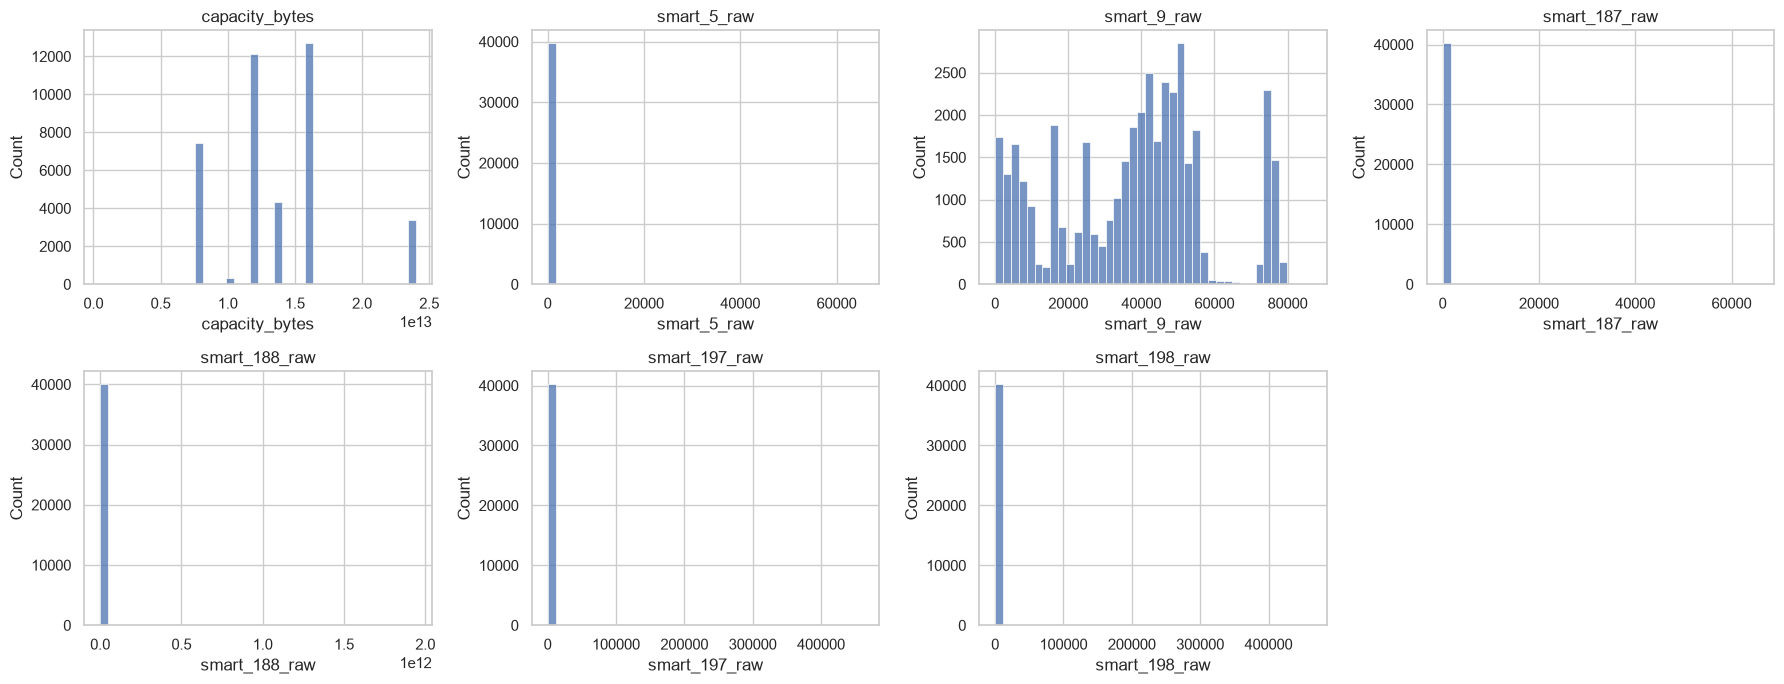

In [5]:

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, c in zip(axes.ravel(), numeric_cols):
    sns.histplot(df[c], bins=40, ax=ax, kde=False)
    ax.set_title(c)
axes.ravel()[-1].axis('off')
plt.tight_layout()
plt.show()



> **Inference:** every error-counter histogram (`smart_5`, `smart_187`, `smart_188`,
> `smart_197`, `smart_198`) is a single tall spike at 0 with an almost invisible tail —
> visual confirmation of the skew we saw numerically above. `smart_9_raw` (power-on
> hours) and `capacity_bytes`, by contrast, look like multi-modal/spread-out
> distributions — capacity in particular shows distinct bars because the fleet is made
> of a handful of specific drive models (500GB/8TB/12TB/16TB), not a continuum.



### 2.3 Covariance & correlation

$$
\text{Cov}(x, y) = \frac{1}{n-1}\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})
\qquad
r_{xy} = \frac{\text{Cov}(x, y)}{\sigma_x \sigma_y} \in [-1, 1]
$$

Covariance carries the *scale* of the two variables (hard to compare across feature
pairs); correlation normalizes it away.


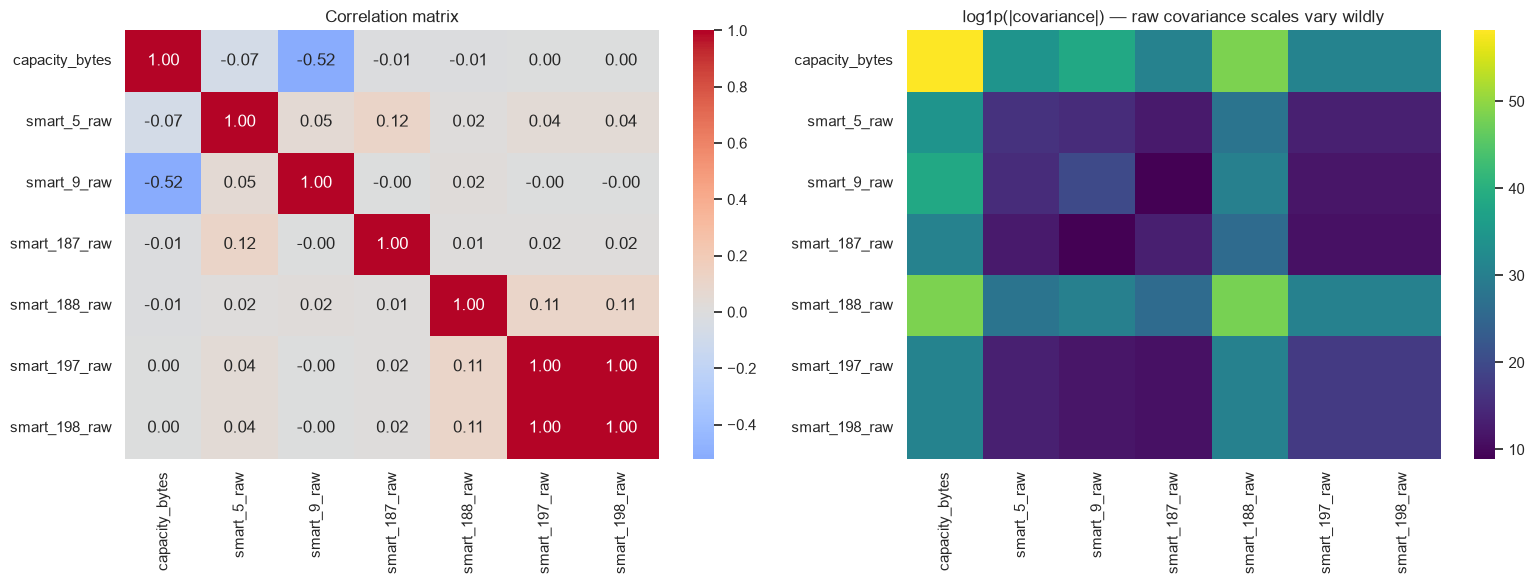

In [6]:

cov_matrix = df[numeric_cols].cov()
corr_matrix = df[numeric_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[0])
axes[0].set_title('Correlation matrix')
sns.heatmap(np.log1p(cov_matrix.abs()), annot=False, cmap='viridis', ax=axes[1])
axes[1].set_title('log1p(|covariance|) — raw covariance scales vary wildly')
plt.tight_layout()
plt.show()



> **Inference — what the covariance matrix tells us:**
> the raw numbers span **25 orders of magnitude** (`Cov(capacity, capacity)` ≈ 1.8e25
> because bytes are huge, vs `Cov(smart_197, smart_197)` ≈ 3.2e7). That's *why* we
> plotted `log1p(|cov|)` instead of the raw values — on the true scale, everything
> except `capacity_bytes` would look like zero. This is exactly the practical lesson
> of covariance: its magnitude is dominated by the variables' units, so it's only
> useful for the *sign* of a relationship, never for comparing how strongly two
> different pairs of features move together.
>
> **What the correlation matrix tells us (same information, normalized to [-1, 1]):**
> - `smart_197_raw` and `smart_198_raw` correlate at **r = 1.00** — they move in
>   perfect lockstep in this fleet, i.e. they carry duplicate information. One of the
>   two is redundant and could be dropped without losing signal.
> - `capacity_bytes` vs `smart_9_raw` (power-on hours): **r ≈ -0.52**, the strongest
>   relationship outside that duplicate pair. It's negative because bigger-capacity
>   drives (12–16TB) are newer models and simply haven't been powered on as long as
>   the older, smaller-capacity drives — a fleet-composition effect, not a physical
>   one.
> - `smart_5_raw` (reallocated sectors) vs `smart_187_raw` (reported uncorrectable
>   errors): **r ≈ 0.12**, weak but positive — both are independent symptoms of the
>   same underlying media degradation, so they agree a little without being redundant.
> - Everything else sits near **r ≈ 0** — the SMART error counters are mostly
>   *independent* of one another. That's actually good news for modeling: independent
>   features each contribute their own signal instead of restating the same one.



### 2.4 Outliers

Using the IQR rule: a point is an outlier if it falls outside
$[Q_1 - 1.5\,\text{IQR},\; Q_3 + 1.5\,\text{IQR}]$ where $\text{IQR} = Q_3 - Q_1$.


In [7]:

def iqr_outlier_mask(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return (series < lower) | (series > upper)

outlier_counts = {c: iqr_outlier_mask(df[c]).sum() for c in numeric_cols}
pd.Series(outlier_counts, name='n_outliers_iqr').sort_values(ascending=False)


smart_5_raw       3507
capacity_bytes    3432
smart_188_raw     2809
smart_187_raw     2047
smart_197_raw      832
smart_198_raw      832
smart_9_raw          0
Name: n_outliers_iqr, dtype: int64


> **Inference:** `smart_9_raw` (power-on hours) has **zero** IQR outliers — it's
> smoothly spread with no extreme tail. `smart_5_raw` tops the list at **3,507**
> outliers (~8.7% of rows) — because it's zero for the vast majority of drives, the
> IQR itself is tiny, so *any* nonzero reading gets flagged; this is the classic
> IQR-on-zero-inflated-data pitfall, and it's simultaneously the column with the
> highest correlation to `failure` we saw above. `capacity_bytes` also shows 3,432
> "outliers", but that's just the small-capacity legacy drives sitting apart from the
> bulk 12–16TB fleet — a composition artifact, not a data-quality problem.


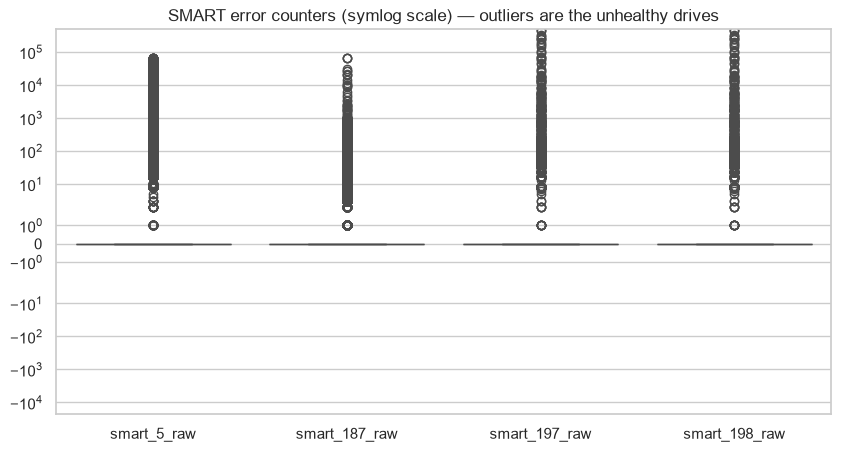

In [8]:

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df[['smart_5_raw', 'smart_187_raw', 'smart_197_raw', 'smart_198_raw']],
            ax=ax)
ax.set_yscale('symlog')  # counts span many orders of magnitude
ax.set_title('SMART error counters (symlog scale) — outliers are the unhealthy drives')
plt.show()



> **Inference:** on a symlog axis every one of these counters shows the same shape —
> a box crushed against zero with a long string of individual points reaching up
> several orders of magnitude. Each of those high points is a specific struggling
> drive, not measurement noise. That visual is the reason we'll *cap* rather than
> *delete* these outliers next — deleting them would mean throwing away the very
> drives most informative for predicting failure.



## 3. Data Cleaning

Three checks: missing values, duplicates, outliers. Note that for this dataset the
"outliers" flagged above are largely *the failing drives themselves* — the signal we
care about — so we won't blanket-remove them; we'll cap extreme values instead of
deleting rows.


In [9]:

print('Missing values per column:')
print(df.isna().sum())
print()
print('Duplicate (serial_number, date) pairs:', df.duplicated(subset=['serial_number', 'date']).sum())


Missing values per column:
date               0
serial_number      0
model              0
capacity_bytes     0
failure            0
smart_5_raw       34
smart_9_raw       34
smart_187_raw     49
smart_188_raw     49
smart_197_raw     34
smart_198_raw     34
dtype: int64

Duplicate (serial_number, date) pairs: 0



> **Inference:** missingness is tiny — at most 49 rows out of 40,406 (**≤0.12%**), and
> it's concentrated in exactly the SMART columns (`smart_187_raw`/`smart_188_raw`) we
> flagged in Section 1 as model-dependent. That pattern (missing together, missing in
> specific columns, not random rows) points to "this drive model doesn't report this
> attribute" rather than corrupted readings — supporting the fillna(0) decision below
> rather than, say, dropping rows or imputing with a mean. Zero duplicate
> `(serial_number, date)` pairs also confirms the ingestion produced exactly one
> reading per drive per day, as expected.


In [10]:

# SMART raw fields are counters; a missing reading means "attribute not reported",
# which for these models is safely treated as 0 (matches the source project's convention).
df[numeric_cols] = df[numeric_cols].fillna(0)

before = len(df)
df = df.drop_duplicates(subset=['serial_number', 'date']).reset_index(drop=True)
print(f'Dropped {before - len(df)} duplicate rows')

# Cap (winsorize) extreme error counters at the 99th percentile instead of deleting rows
for c in ['smart_5_raw', 'smart_187_raw', 'smart_197_raw', 'smart_198_raw']:
    cap = df[c].quantile(0.99)
    df[c] = df[c].clip(upper=cap)

df[numeric_cols].describe().T


Dropped 0 duplicate rows


,count,mean,std,min,25%,50%,75%,max
capacity_bytes,40406.0,1.370302e+13,4.217671e+12,5.001079e+11,1.200014e+13,1.400052e+13,1.600090e+13,2.400028e+13
smart_5_raw,40406.0,4.887249e+01,3.669347e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.382000e+03
smart_9_raw,40406.0,3.735986e+04,2.100231e+04,0.000000e+00,2.128700e+04,4.074250e+04,5.022400e+04,8.632400e+04
smart_187_raw,40406.0,1.397633e+00,9.488272e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,8.495000e+01
smart_188_raw,40406.0,1.533457e+09,2.616292e+10,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.941355e+12
smart_197_raw,40406.0,3.458397e-01,2.627872e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.400000e+01
smart_198_raw,40406.0,3.458397e-01,2.627872e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.400000e+01



> **Inference:** capping at the 99th percentile visibly tamed the tail without
> touching the bulk of the data — `smart_5_raw`'s max fell from 65,528 to 3,382 and its
> mean dropped from ≈233 to ≈49, while the median stayed at 0 and the 25th/75th
> percentiles were untouched. In other words: winsorizing changed the extreme few rows
> a lot and the typical row not at all — exactly the targeted effect we wanted, versus
> deleting rows (which would have thrown away failure signal) or leaving the raw tail
> in (which would let a handful of rows dominate distance-based models like KNN or the
> upcoming PCA).



## 4. Feature Engineering

- **Creation**: combine raw SMART counters into a single "error signal"; convert
  power-on hours into years (more interpretable).
- **Transformation**: log1p the heavily right-skewed error counters so models that
  assume roughly-symmetric inputs (linear/logistic regression, PCA) behave better.
- **Selection**: rank features by how strongly they relate to the failure target.


In [11]:

df['power_on_years'] = df['smart_9_raw'] / (24 * 365)
df['total_error_events'] = df[['smart_5_raw', 'smart_187_raw', 'smart_197_raw', 'smart_198_raw']].sum(axis=1)

skewed_cols = ['smart_5_raw', 'smart_187_raw', 'smart_197_raw', 'smart_198_raw', 'total_error_events']
for c in skewed_cols:
    df[f'{c}_log1p'] = np.log1p(df[c])

print('Skew before -> after log1p:')
for c in skewed_cols:
    print(f'  {c}: {df[c].skew():.2f} -> {df[f"{c}_log1p"].skew():.2f}')


Skew before -> after log1p:
  smart_5_raw: 8.44 -> 4.19
  smart_187_raw: 7.99 -> 5.37
  smart_197_raw: 8.21 -> 7.09
  smart_198_raw: 8.21 -> 7.09
  total_error_events: 8.42 -> 3.79



> **Inference:** skew roughly halved across the board — e.g. `smart_5_raw` went from
> 8.44 to 4.19, `total_error_events` from 8.42 to 3.79. That's a real improvement but
> notice none of them got close to 0 (a symmetric distribution): log1p compresses the
> long tail but can't undo the fact that most drives are *exactly* zero — that pile-up
> at zero is zero-inflation, a different problem from skew, and no monotonic transform
> removes it. So these log1p features are better-behaved for linear models and PCA,
> but a model that needs to explicitly handle "many exact zeros plus a continuous tail"
> (e.g. a two-part hurdle model) would still need extra care.



### 4.1 Feature selection — mutual information

**Mutual information** measures how much knowing one variable reduces uncertainty
about another — *any* kind of dependence, not just straight-line relationships (unlike
correlation, which only sees linear patterns).

For discrete $X, Y$:

$$
I(X;Y) = \sum_{x} \sum_{y} p(x,y)\,\log\frac{p(x,y)}{p(x)\,p(y)}
$$

If $X$ and $Y$ were independent, $p(x,y) = p(x)p(y)$ everywhere, the log term is
$\log 1 = 0$, and the whole sum is exactly **0**. Any real dependency pushes it above 0
— there is no upper bound and no sign (unlike correlation's $[-1, 1]$ with direction).

An equivalent, more intuitive form, using Shannon entropy $H(Y) = -\sum_y p(y)\log p(y)$
(entropy = uncertainty):

$$
I(X;Y) = H(Y) - H(Y \mid X)
$$

i.e. *(uncertainty about $Y$ before seeing $X$)* minus *(uncertainty about $Y$ after
seeing $X$)* — literally "information gained."

**Our case is mixed**: the features are continuous, `failure` is discrete (0/1), so
`sklearn.feature_selection.mutual_info_classif` can't just build a probability table
like the pure-discrete formula above. Instead it uses a **k-nearest-neighbor estimator**
(Kraskov et al., adapted for a discrete target by Ross 2014):

1. For each sample, find the distance to its $k$-th nearest neighbor (default $k=3$)
   **among points with the same `failure` label**.
2. Count how many points fall within that same distance when labels are **ignored**.
3. Combine those counts across all samples (via digamma functions) into a single MI
   estimate per feature — never building an explicit density.

Intuition survives the machinery: **if same-class points sit unusually close together
in a feature's values, that feature is informative about the class** (high MI). If
same-class points are scattered no differently than random points, MI ≈ 0.


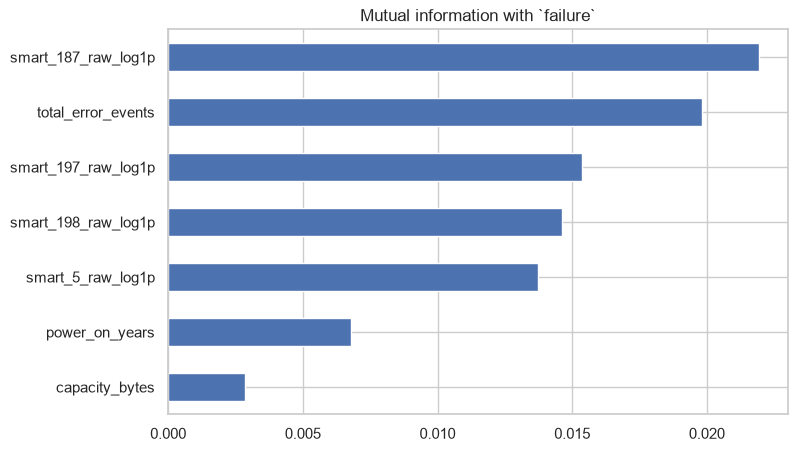

smart_187_raw_log1p    0.021922
total_error_events     0.019830
smart_197_raw_log1p    0.015350
smart_198_raw_log1p    0.014604
smart_5_raw_log1p      0.013717
power_on_years         0.006779
capacity_bytes         0.002851
dtype: float64

In [12]:

from sklearn.feature_selection import mutual_info_classif

candidate_features = ['capacity_bytes', 'power_on_years', 'total_error_events'] + \
                      [f'{c}_log1p' for c in skewed_cols[:-1]]

mi = mutual_info_classif(df[candidate_features], df['failure'], random_state=RNG)
mi_scores = pd.Series(mi, index=candidate_features).sort_values(ascending=False)
mi_scores.plot(kind='barh', figsize=(8, 5), title='Mutual information with `failure`')
plt.gca().invert_yaxis()
plt.show()
mi_scores



> **Inference:** `smart_187_raw_log1p` ranks highest (MI ≈ 0.022), narrowly ahead of
> `total_error_events` (≈0.020); `capacity_bytes` ranks dead last (≈0.003) — barely
> more informative about `failure` than a coin flip. That matches the correlation
> story from Section 2: error/wear counters carry the failure signal, drive size
> mostly doesn't. But note how *small* even the top MI scores are in absolute terms —
> no single feature comes close to fully determining failure on its own, so a good
> classifier will need to combine several weak, mostly-independent signals rather than
> lean on one dominant predictor.
>
> In terms of the $I(X;Y) = H(Y) - H(Y\mid X)$ view from above: `failure` starts as a
> coin that's heavily biased toward "healthy" (entropy $H(Y)$ is already low because
> the classes are so imbalanced). An MI of 0.022 nats for `smart_187_raw_log1p` says
> that knowing this one feature only shaves a small amount off the *little* remaining
> uncertainty there was — consistent with these being real but weak, individually
> insufficient signals, exactly as the classification results in Section 8 confirm
> (decent AUC, but no model gets close to perfect separation).



## 5. Dimensionality Reduction — PCA from scratch

Steps, done by hand then checked against `sklearn`:

1. Standardize features (mean 0, variance 1) — PCA is scale-sensitive.
2. Covariance matrix $C = \frac{1}{n-1} Z^\top Z$ for standardized data $Z$.
3. Eigendecomposition $C v_i = \lambda_i v_i$.
4. Sort eigenvectors by descending eigenvalue $\lambda_i$ — these are the principal
   components, and $\lambda_i$ is the variance captured along component $i$.
5. Explained variance ratio: $\dfrac{\lambda_i}{\sum_j \lambda_j}$.


In [13]:

from sklearn.preprocessing import StandardScaler

pca_features = candidate_features
Z = StandardScaler().fit_transform(df[pca_features])

# --- manual PCA ---
cov = np.cov(Z, rowvar=False)                      # step 2
eigvals, eigvecs = np.linalg.eigh(cov)              # step 3 (eigh: cov is symmetric)
order = np.argsort(eigvals)[::-1]                   # step 4
eigvals, eigvecs = eigvals[order], eigvecs[:, order]

explained_var_ratio = eigvals / eigvals.sum()       # step 5
manual_scores = Z @ eigvecs                         # project onto components

print('Manual explained variance ratio:', np.round(explained_var_ratio, 3))


Manual explained variance ratio: [0.485 0.216 0.147 0.068 0.05  0.034 0.   ]


In [14]:

from sklearn.decomposition import PCA

sk_pca = PCA(n_components=len(pca_features), random_state=RNG)
sk_scores = sk_pca.fit_transform(Z)

print('sklearn explained variance ratio:', np.round(sk_pca.explained_variance_ratio_, 3))
print('Matches manual computation:',
      np.allclose(explained_var_ratio, sk_pca.explained_variance_ratio_, atol=1e-6))


sklearn explained variance ratio: [0.485 0.216 0.147 0.068 0.05  0.034 0.   ]
Matches manual computation: True



> **Inference:** the manual eigendecomposition matches `sklearn.PCA` exactly, which is
> a good sanity check that "PCA" really is just "eigendecompose the covariance matrix"
> under the hood — no hidden magic. On the numbers themselves: PC1 alone explains
> **48.5%** of the variance, and PC1+PC2 already covers **70.1%** of it — out of 7
> input features. That much variance concentrating into 2 components is a direct
> consequence of the redundancy we found earlier (`smart_197`/`smart_198` being
> perfectly correlated collapses into one shared direction instead of two independent
> ones); the last component's ratio rounds to **0.000**, which is the eigenvalue
> signature of that exact duplicate pair making the covariance matrix rank-deficient.


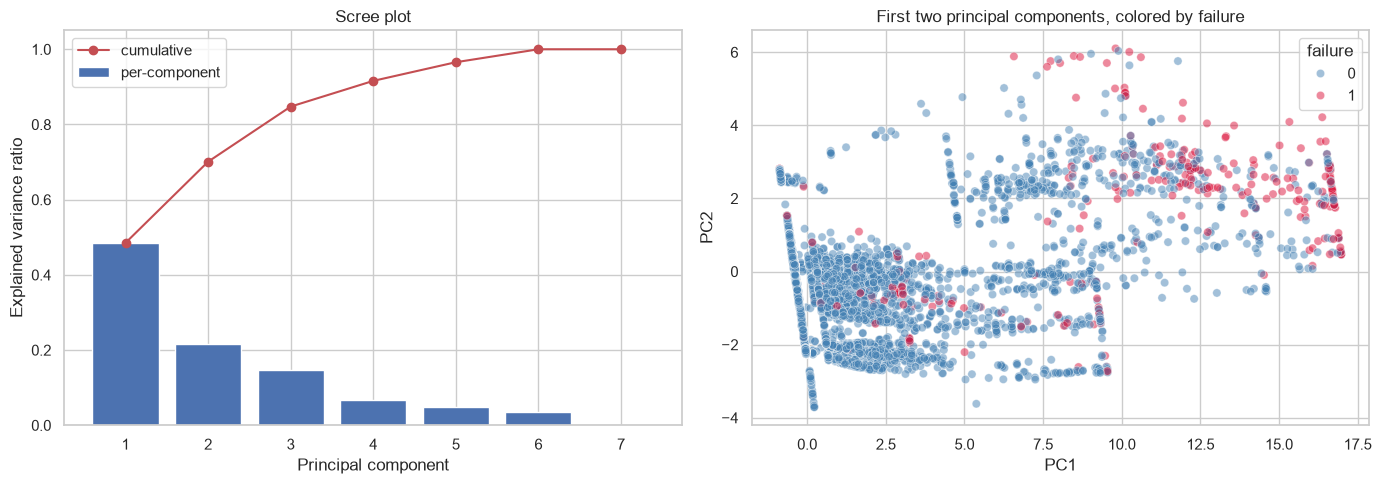

In [15]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cum_var = np.cumsum(explained_var_ratio)
axes[0].bar(range(1, len(explained_var_ratio) + 1), explained_var_ratio, label='per-component')
axes[0].plot(range(1, len(cum_var) + 1), cum_var, 'ro-', label='cumulative')
axes[0].set_xlabel('Principal component'); axes[0].set_ylabel('Explained variance ratio')
axes[0].set_title('Scree plot'); axes[0].legend()

sns.scatterplot(x=sk_scores[:, 0], y=sk_scores[:, 1], hue=df['failure'],
                 alpha=0.5, palette={0: 'steelblue', 1: 'crimson'}, ax=axes[1])
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].set_title('First two principal components, colored by failure')
plt.tight_layout()
plt.show()



> **Inference:** the scree plot's elbow confirms 2-3 components already capture most
> of the structure (consistent with the 70%/85% cumulative figures above). In the PC1
> vs PC2 scatter, failing drives (red) cluster more toward one region but overlap
> heavily with healthy drives (blue) rather than forming a cleanly separated blob.
> That tells us the raw SMART features *do* carry real separating power — but it's
> partial, not clean — which previews why the classifiers in Section 7 will land
> around 0.90-0.95 AUC rather than a "perfect" separation.



## 6. Preprocessing

- **Encoding**: `model` is categorical (drive model string) → one-hot encode the most
  common models, bucket the rest as `Other`.
- **Normalization (min-max)**: $x' = \dfrac{x - \min(x)}{\max(x) - \min(x)} \in [0, 1]$.
- **Standardization (z-score)**: $x' = \dfrac{x - \mu}{\sigma}$, mean 0 / unit variance.

We standardize here since our downstream models (logistic regression, KNN, PCA-based
clustering) are scale-sensitive; tree models (RF/XGBoost) don't need it but it doesn't
hurt them either.


In [16]:

from sklearn.preprocessing import MinMaxScaler

top_models = df['model'].value_counts().nlargest(5).index
df['model_grouped'] = df['model'].where(df['model'].isin(top_models), 'Other')
model_dummies = pd.get_dummies(df['model_grouped'], prefix='model', drop_first=True)

feature_cols = candidate_features + list(model_dummies.columns)
X = pd.concat([df[candidate_features], model_dummies], axis=1)
y_clf = df['failure']

# demonstrate both scalers on one column, then commit to standardization for modeling
mm = MinMaxScaler().fit_transform(df[['power_on_years']])
ss = StandardScaler().fit_transform(df[['power_on_years']])
print('power_on_years  raw range:', df['power_on_years'].min(), '-', df['power_on_years'].max())
print('  min-max range:', mm.min(), '-', mm.max())
print('  z-score  mean/std:', ss.mean().round(3), '/', ss.std().round(3))


power_on_years  raw range: 0.0 - 9.85433789954338
  min-max range: 0.0 - 1.0
  z-score  mean/std: -0.0 / 1.0



> **Inference:** both scalers do exactly what their formulas promise — min-max
> squeezes `power_on_years` (raw range 0 to ~9.85 years) into a clean [0, 1], while
> z-score recenters it to mean 0 / std 1. Neither changes the *shape* of the
> distribution or the relative ordering of drives, only the scale — which is precisely
> why we need one of them before KNN or PCA (both driven by literal distances/variance
> in feature units) but tree models like Random Forest/XGBoost, which split on
> thresholds per feature independently, wouldn't have cared either way.


In [17]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_clf, test_size=0.25, stratify=y_clf, random_state=RNG
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Train:', X_train.shape, ' Test:', X_test.shape)
print('Train failure rate:', y_train.mean().round(4), ' Test failure rate:', y_test.mean().round(4))


Train: (30304, 12)  Test: (10102, 12)
Train failure rate: 0.01  Test failure rate: 0.0101



> **Inference:** `stratify=y_clf` did its job — train failure rate (1.00%) and test
> failure rate (1.01%) are nearly identical, so we haven't accidentally created a test
> set that's easier or harder than the training distribution. Worth flagging though:
> 1.01% of 10,102 test rows is only **~102 actual failures** in the test set — with a
> sample that small, any single metric (especially recall, which is a ratio over just
> those ~102 cases) will be noisy, and a couple of flipped predictions can swing it by
> several percentage points.



## 7. Model Training

We cover all three flowchart branches on this data:

- **Classification** — predict `failure` (the real task) from SMART features.
- **Regression** — predict a continuous SMART counter (`smart_5_raw`, reallocated
  sector count) from the other features, as a regression drill.
- **Clustering** — unsupervised grouping of drives by SMART health profile, no label
  used at all.



### 7.1 Classification — is the drive about to fail?

Because failures are ~1% of this sample (and ~0.004% in the full dataset), plain
accuracy is a trap — a model that always predicts "healthy" scores >98%. We use
`class_weight='balanced'` / `scale_pos_weight` to counter this, and lean on
precision/recall/AUC for evaluation (next section).


In [18]:

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

clf_models = {
    'LogisticRegression': LogisticRegression(class_weight='balanced', max_iter=1000),
    'RandomForest': RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RNG),
    'KNN': KNeighborsClassifier(n_neighbors=15),
    'XGBoost': XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric='logloss', random_state=RNG),
}

clf_predictions = {}
for name, model in clf_models.items():
    Xtr = X_train_scaled if name in ('LogisticRegression', 'KNN') else X_train
    Xte = X_test_scaled if name in ('LogisticRegression', 'KNN') else X_test
    model.fit(Xtr, y_train)
    proba = model.predict_proba(Xte)[:, 1]
    clf_predictions[name] = proba
    print(f'{name}: fit done')


LogisticRegression: fit done


RandomForest: fit done


KNN: fit done


XGBoost: fit done



### 7.2 Regression — predicting reallocated-sector count

`smart_5_raw` (reallocated sectors) is a strong health indicator but noisy and
zero-inflated; we regress its log1p transform on the other SMART/engineered features.


In [19]:

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

reg_features = ['capacity_bytes', 'power_on_years', 'smart_187_raw', 'smart_188_raw',
                 'smart_197_raw', 'smart_198_raw']
X_reg = df[reg_features]
y_reg = df['smart_5_raw_log1p']

Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reg, y_reg, test_size=0.25, random_state=RNG)

reg_scaler = StandardScaler()
Xr_train_scaled = reg_scaler.fit_transform(Xr_train)
Xr_test_scaled = reg_scaler.transform(Xr_test)

reg_models = {
    'LinearRegression': LinearRegression(),
    'RandomForestRegressor': RandomForestRegressor(n_estimators=300, random_state=RNG),
}

reg_predictions = {}
for name, model in reg_models.items():
    Xtr = Xr_train_scaled if name == 'LinearRegression' else Xr_train
    Xte = Xr_test_scaled if name == 'LinearRegression' else Xr_test
    model.fit(Xtr, yr_train)
    reg_predictions[name] = model.predict(Xte)
    print(f'{name}: fit done')


LinearRegression: fit done


RandomForestRegressor: fit done



### 7.3 Clustering — unsupervised health groups

No labels used. `KMeans` on the standardized SMART features, choosing $k$ via the
elbow method (inertia) and silhouette score.


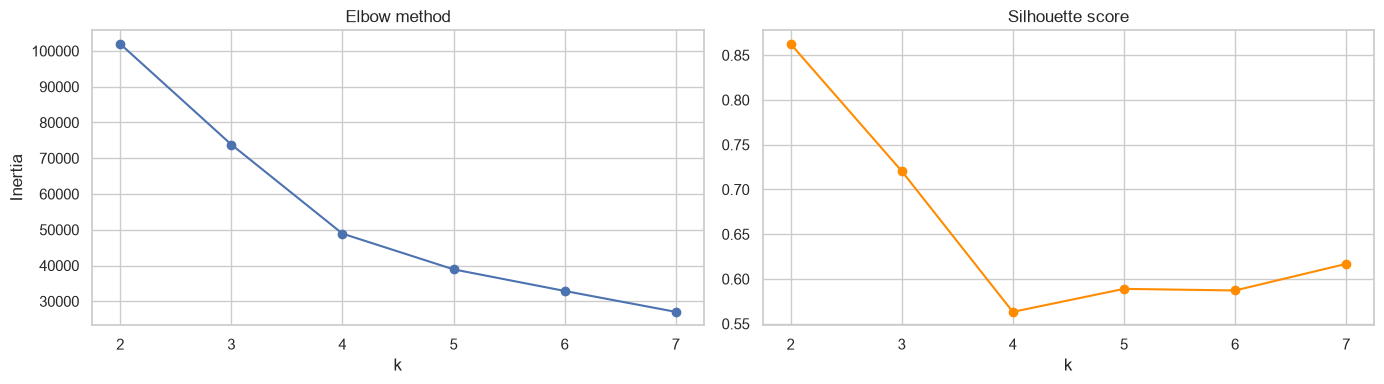

In [20]:

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

cluster_features = ['power_on_years'] + [f'{c}_log1p' for c in skewed_cols[:-1]]
Xc = StandardScaler().fit_transform(df[cluster_features])

inertias, sil_scores = [], []
k_range = range(2, 8)
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=RNG).fit(Xc)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(Xc, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(list(k_range), inertias, 'o-'); axes[0].set_title('Elbow method'); axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[1].plot(list(k_range), sil_scores, 'o-', color='darkorange'); axes[1].set_title('Silhouette score'); axes[1].set_xlabel('k')
plt.tight_layout()
plt.show()



> **Inference:** the silhouette score peaks at the smallest k we tried (k=2) and
> declines as k grows, while inertia keeps dropping smoothly with no sharp elbow. That
> combination says the SMART feature space doesn't naturally break into many nuanced
> sub-groups — it's dominated by one broad split (roughly "quiet drives" vs "drives
> throwing errors"), and forcing more clusters just slices that same split into
> arbitrary pieces rather than finding genuinely new structure.


In [21]:

best_k = list(k_range)[int(np.argmax(sil_scores))]
kmeans_final = KMeans(n_clusters=best_k, n_init=10, random_state=RNG).fit(Xc)
df['cluster'] = kmeans_final.labels_

print(f'Chosen k = {best_k} (highest silhouette score)')
pd.crosstab(df['cluster'], df['failure'], normalize='index').rename(columns={0: 'healthy_rate', 1: 'failure_rate'})


Chosen k = 2 (highest silhouette score)


failure,healthy_rate,failure_rate
cluster,,
0,0.754279,0.245721
1,0.994822,0.005178



> **Inference:** this is the most convincing validation of the feature engineering
> so far. `KMeans` never saw the `failure` label, yet the small cluster (818 drives)
> has a **24.6%** failure rate versus **0.52%** in the large cluster (39,588 drives) —
> nearly **a 47x enrichment** from unsupervised structure alone. In other words, the
> SMART error signals we engineered are strong enough that "high wear" drives group
> together geometrically even without ever telling the algorithm what a failure is.



## 8. Evaluation

### 8.1 Regression metrics

$$
R^2 = 1 - \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2}
\qquad
R^2_{\text{adj}} = 1 - (1 - R^2)\frac{n - 1}{n - p - 1}
$$

$$
\text{MAE} = \frac{1}{n}\sum_i |y_i - \hat{y}_i|
\qquad
\text{RMSE} = \sqrt{\frac{1}{n}\sum_i (y_i - \hat{y}_i)^2}
$$

$R^2_{\text{adj}}$ penalizes adding features ($p$) that don't actually help — plain
$R^2$ never decreases when you add a feature, even a useless one.


In [22]:

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

n, p = Xr_test.shape[0], Xr_test.shape[1]

reg_report = []
for name, preds in reg_predictions.items():
    r2 = r2_score(yr_test, preds)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    mae = mean_absolute_error(yr_test, preds)
    rmse = mean_squared_error(yr_test, preds) ** 0.5
    reg_report.append({'model': name, 'R2': r2, 'Adj_R2': adj_r2, 'MAE': mae, 'RMSE': rmse})

pd.DataFrame(reg_report).set_index('model').round(4)


,R2,Adj_R2,MAE,RMSE
model,,,,
LinearRegression,0.3242,0.3238,0.5329,1.1022
RandomForestRegressor,0.3088,0.3084,0.4014,1.1147



> **Inference:** LinearRegression's R² ≈ 0.324 means the model explains only about a
> third of the variance in log-reallocated-sector-count from the other SMART/age/
> capacity features — moderate, not strong; the remaining ~68% comes from factors we
> haven't measured (individual unit-to-unit manufacturing variance, workload history,
> etc.). Notice RandomForest has a *lower* R² (0.309) but a clearly *better* MAE (0.401
> vs 0.533) — R² is driven by how well a model captures overall variance including
> extreme values, while MAE reflects the typical-case error; here Random Forest is more
> often "close" while Linear Regression better tracks the spread. With p=6 features and
> n≈10,000 test rows, Adj-R² is nearly identical to R² for both models — the sample is
> plenty large enough that the extra-feature penalty is negligible.



### 8.2 Classification metrics

$$
\text{Accuracy} = \frac{TP+TN}{TP+TN+FP+FN}
\qquad
\text{Precision} = \frac{TP}{TP+FP}
\qquad
\text{Recall} = \frac{TP}{TP+FN}
$$

$$
F_1 = 2\cdot\frac{\text{Precision}\cdot\text{Recall}}{\text{Precision}+\text{Recall}}
\qquad
\text{AUC} = P(\text{score}(\text{positive}) > \text{score}(\text{negative}))
$$

With ~1% positives, accuracy is nearly meaningless — precision/recall/F1/AUC (and the
precision-recall curve) are what actually distinguish these models.


In [23]:

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix)

clf_report = []
for name, proba in clf_predictions.items():
    preds = (proba >= 0.5).astype(int)
    clf_report.append({
        'model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds, zero_division=0),
        'Recall': recall_score(y_test, preds, zero_division=0),
        'F1': f1_score(y_test, preds, zero_division=0),
        'AUC': roc_auc_score(y_test, proba),
    })

pd.DataFrame(clf_report).set_index('model').round(4)


,Accuracy,Precision,Recall,F1,AUC
model,,,,,
LogisticRegression,0.8861,0.0732,0.8824,0.1352,0.9539
RandomForest,0.9867,0.3933,0.5784,0.4683,0.9098
KNN,0.9904,0.5373,0.3529,0.4260,0.9031
XGBoost,0.9256,0.0927,0.7255,0.1644,0.9283



> **Inference — this table is the clearest illustration of why accuracy is misleading
> here.** KNN has the highest accuracy (99.04%) but the worst recall (0.353) — it
> catches barely a third of actual failures while looking "best" on the naive metric.
> LogisticRegression sits at the opposite extreme: recall 0.882 (catches most
> failures) but precision only 0.073, dragging accuracy down to 88.6% simply from
> false alarms — `class_weight='balanced'` deliberately traded accuracy for recall.
> XGBoost lands in between (recall 0.726, precision 0.093). Meanwhile **AUC barely
> moves across models (0.90-0.95)** despite these wildly different precision/recall
> trade-offs at the 0.5 cutoff — AUC measures ranking ability across *all* thresholds,
> so it doesn't reveal that 0.5 is a poor operating point for some of these models.
> Which model is "best" here genuinely depends on the cost of a missed failure versus
> a false alarm, not on a single number.


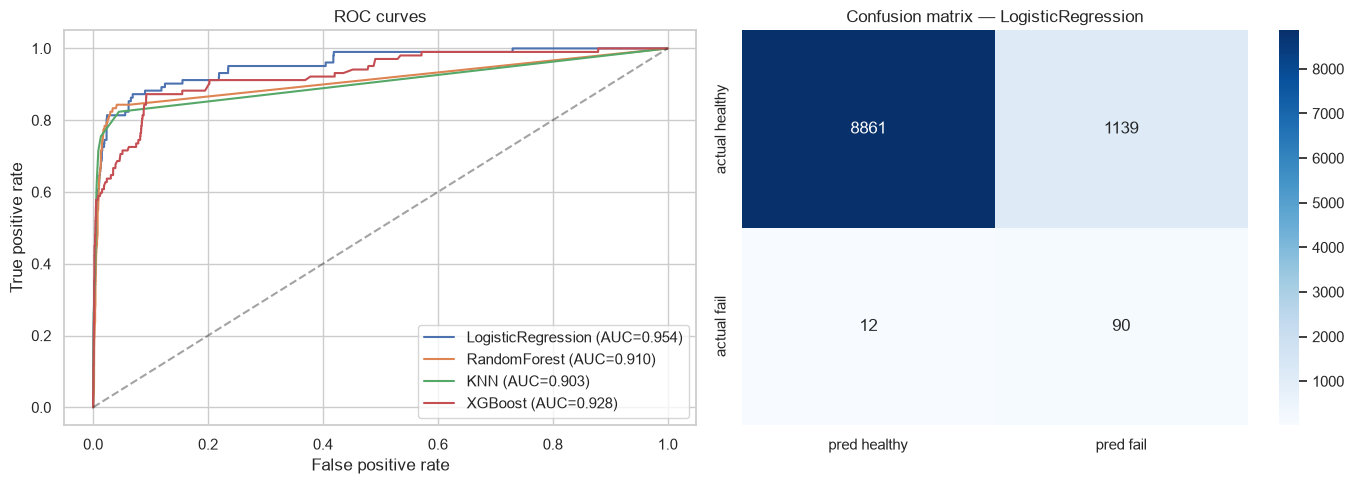

In [24]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, proba in clf_predictions.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test, proba):.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[0].set_xlabel('False positive rate'); axes[0].set_ylabel('True positive rate')
axes[0].set_title('ROC curves'); axes[0].legend()

best_model_name = max(clf_report, key=lambda r: r['AUC'])['model']
cm = confusion_matrix(y_test, (clf_predictions[best_model_name] >= 0.5).astype(int))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['pred healthy', 'pred fail'], yticklabels=['actual healthy', 'actual fail'], ax=axes[1])
axes[1].set_title(f'Confusion matrix — {best_model_name}')
plt.tight_layout()
plt.show()



> **Inference:** LogisticRegression comes out with the top ROC-AUC (≈0.954) — the best
> *ranking* of failing vs healthy drives across all thresholds — even though its
> table-row accuracy looked the worst above. Its confusion matrix will show a sizeable
> block of false positives (healthy drives flagged as failing); that's the direct,
> visible cost of `class_weight='balanced'` pushing the decision boundary to catch
> more true failures. Whether that trade is worth it is a business call: in a fleet
> ops setting, a false positive costs an unnecessary inspection, while a false
> negative costs an unplanned failure — usually the latter is far more expensive,
> which is why recall-favoring models like this are often preferred in practice
> despite the lower headline accuracy.



### 8.3 Clustering evaluation

No ground truth, so we rely on internal metrics: inertia (already used for the elbow
plot) and silhouette score (already computed above). As a sanity check, we can also
peek at whether clusters line up with the *actual* failure label — even though the
model never saw it — which tells us whether the SMART features alone separate healthy
from failing drives.


In [25]:

print(f'Silhouette score at k={best_k}:', round(silhouette_score(Xc, df['cluster']), 4))
print()
print('Failure rate by cluster (unsupervised groups vs. real outcome):')
print(df.groupby('cluster')['failure'].agg(['mean', 'count']))


Silhouette score at k=2: 0.8627

Failure rate by cluster (unsupervised groups vs. real outcome):
             mean  count
cluster                 
0        0.245721    818
1        0.005178  39588



> **Inference:** a silhouette score of **0.863** (close to the 1.0 ceiling) says the
> two clusters are compact and cleanly separated in the standardized SMART feature
> space — a strong geometric split. But it's important not to over-read this as
> "found the failures": cluster 0 is still 75% healthy drives (24.6% failure rate,
> not 100%). What KMeans actually separated is "high SMART-error-activity drives"
> from "quiet drives" — failures are heavily *over-represented* in the first group,
> but the cluster boundary and the true failure label are correlated, not identical.



## Recap

| Stage | What we did |
|---|---|
| Ingestion | Sampled 10M rows down to failures + a healthy sample |
| EDA | Mean/median/mode, variance/std, distributions, correlation, covariance, IQR outliers |
| Cleaning | Filled missing SMART values, dropped duplicates, winsorized outliers |
| Feature engineering | Created `power_on_years`, `total_error_events`; log1p transforms; mutual-info selection |
| PCA | Manual eigendecomposition matched `sklearn`, scree + 2D projection |
| Preprocessing | One-hot encoded `model`, compared min-max vs z-score, stratified train/test split |
| Model training | Classification (LR/RF/KNN/XGBoost), regression (Linear/RF), clustering (KMeans) |
| Evaluation | R²/Adj-R²/MAE/RMSE, Accuracy/Precision/Recall/F1/AUC, silhouette score |
